In [1]:
import os
import zipfile
from io import BytesIO

import cv2
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

### CIFAR100

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transformations (resize for Vision Transformer)
transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),  # Resize images to 224x224 for ViT
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408], std=[0.2675, 0.2565, 0.2761]
        ),
    ]
)

# Load CIFAR-100 train and test sets
train_dataset = datasets.CIFAR100(
    root="./data", train=True, transform=transform, download=True
)
test_dataset = datasets.CIFAR100(
    root="./data", train=False, transform=transform, download=True
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

Files already downloaded and verified
Files already downloaded and verified


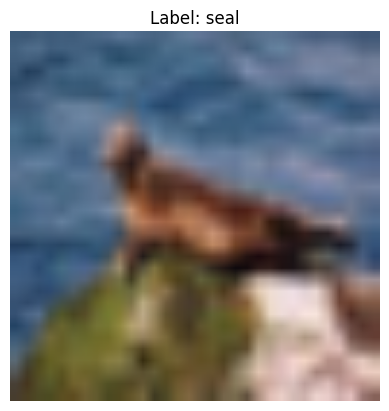

In [19]:
# Select an image and its label from the test dataset
image, label = test_dataset[2]  # Access the first image in the test set

# De-normalize the image for proper display
image = image * torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1) + torch.tensor(
    [0.5071, 0.4867, 0.4408]
).view(3, 1, 1)
image = image.clip(0, 1)  # Clip values to the range [0, 1]

# Plot the image with its label
plt.imshow(image.permute(1, 2, 0))  # Rearrange dimensions for plotting
plt.title(f"Label: {test_dataset.classes[label]}")
plt.axis("off")
plt.show()

## Build a ViT classifier

In [20]:
prefix = "untrained_"

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiheadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(MultiheadSelfAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert (
            self.head_dim * num_heads == embed_dim
        ), "embed_dim must be divisible by num_heads"

        # Linear layers for query, key, and value
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        batch_size, num_tokens, embed_dim = x.size()

        # Project input to queries, keys, and values and reshape for multi-head attention
        q = (
            self.q_proj(x)
            .reshape(batch_size, num_tokens, self.num_heads, self.head_dim)
            .transpose(1, 2)
        )
        k = (
            self.k_proj(x)
            .reshape(batch_size, num_tokens, self.num_heads, self.head_dim)
            .transpose(1, 2)
        )
        v = (
            self.v_proj(x)
            .reshape(batch_size, num_tokens, self.num_heads, self.head_dim)
            .transpose(1, 2)
        )

        # Calculate attention scores with scaled dot-product
        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn_weights = F.softmax(
            attn_scores, dim=-1
        )  # Shape: [batch, num_heads, num_tokens, num_tokens]

        # Weighted sum of values
        attn_output = torch.matmul(
            attn_weights, v
        )  # Shape: [batch, num_heads, num_tokens, head_dim]
        attn_output = attn_output.transpose(1, 2).reshape(
            batch_size, num_tokens, embed_dim
        )  # Concatenate heads
        output = self.out_proj(attn_output)

        return output, attn_weights  # Return both output and attention scores


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super(TransformerBlock, self).__init__()
        self.attention = MultiheadSelfAttention(embed_dim, num_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Attention and Residual Connection
        attn_output, attn_weights = self.attention(self.norm1(x))
        x = x + self.dropout(attn_output)

        # Feed-forward Network and Residual Connection
        x = x + self.dropout(self.mlp(self.norm2(x)))
        return x, attn_weights  # Return attention weights for each block


class VisionTransformer(nn.Module):
    def __init__(
        self,
        img_size=224,
        patch_size=16,
        embed_dim=768,
        num_layers=12,
        num_heads=12,
        num_classes=1000,
    ):
        super(VisionTransformer, self).__init__()
        self.patch_size = patch_size
        num_patches = (img_size // patch_size) ** 2
        self.embed_dim = embed_dim
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        self.patch_embed = nn.Conv2d(
            3, embed_dim, kernel_size=patch_size, stride=patch_size
        )
        self.transformer_blocks = nn.ModuleList(
            [TransformerBlock(embed_dim, num_heads) for _ in range(num_layers)]
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # Patch Embedding
        x = self.patch_embed(x).flatten(2).transpose(1, 2)

        # Add CLS token and position embeddings
        cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embedding

        # Transformer blocks with attention scores
        attn_weights_all = []
        for block in self.transformer_blocks:
            x, attn_weights = block(x)
            attn_weights_all.append(attn_weights)  # Collect attention scores per block

        x = self.norm(x)
        return (
            self.fc(x[:, 0]),
            attn_weights_all,
        )  # Return both class logits and attention scores

In [22]:
# Assume VisionTransformer is a defined or imported model class
model = VisionTransformer(
    img_size=224,
    patch_size=16,
    embed_dim=768,
    num_layers=12,
    num_heads=12,
    num_classes=100,
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

VisionTransformer(
  (patch_embed): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (transformer_blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (attention): MultiheadSelfAttention(
        (q_proj): Linear(in_features=768, out_features=768, bias=True)
        (k_proj): Linear(in_features=768, out_features=768, bias=True)
        (v_proj): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=768, out_features=3072, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=3072, out_features=768, bias=True)
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=768, out_fe

#### Train

In [23]:
from torch import nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

In [28]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Wrap the dataloader in tqdm
    for images, labels in tqdm(
        dataloader, desc=f"Training Epoch {epoch+1}", leave=False
    ):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs, _ = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy


def evaluate(model, dataloader, criterion, device, epoch):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(
            dataloader, desc=f"Evaluating Epoch {epoch+1}", leave=False
        ):
            images, labels = images.to(device), labels.to(device)
            outputs, _ = model(images)
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy

In [29]:
epoch = 0

In [30]:
from tqdm import tqdm

num_epochs = 20
best_accuracy = 0.0

for epoch in range(num_epochs):
    print(f"\nStarting Epoch - {epoch+1}/{num_epochs}")

    # Wrap the training loop with tqdm for a progress bar
    train_loss, train_accuracy = train_one_epoch(
        model, train_loader, criterion, optimizer, device, epoch
    )

    # Wrap the evaluation loop with tqdm for a progress bar
    test_loss, test_accuracy = evaluate(model, test_loader, criterion, device, epoch)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.4f}"
    )

    # Save the model if it achieves the best accuracy so far
    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        torch.save(model.state_dict(), "data/best_vit_cifar100.pth")


Starting Epoch - 1/20


Epoch [1/20] - Train Loss: 3.5666, Train Acc: 0.1493, Test Loss: 3.4363, Test Acc: 0.1753

Starting Epoch - 2/20


Epoch [2/20] - Train Loss: 3.1692, Train Acc: 0.2191, Test Loss: 3.1011, Test Acc: 0.2359

Starting Epoch - 3/20


Epoch [3/20] - Train Loss: 2.8882, Train Acc: 0.2732, Test Loss: 2.8895, Test Acc: 0.2762

Starting Epoch - 4/20


Epoch [4/20] - Train Loss: 2.6382, Train Acc: 0.3215, Test Loss: 2.6395, Test Acc: 0.3277

Starting Epoch - 5/20


...

Epoch [15/20] - Train Loss: 0.2391, Train Acc: 0.9279, Test Loss: 3.1108, Test Acc: 0.4041

Starting Epoch - 16/20


Epoch [17/20] - Train Loss: 0.1899, Train Acc: 0.9421, Test Loss: 3.2592, Test Acc: 0.4208

Starting Epoch - 18/20


Epoch [18/20] - Train Loss: 0.1765, Train Acc: 0.9461, Test Loss: 3.3713, Test Acc: 0.4057

Starting Epoch - 19/20


Epoch [19/20] - Train Loss: 0.1609, Train Acc: 0.9506, Test Loss: 3.4522, Test Acc: 0.3990

Starting Epoch - 20/20


KeyboardInterrupt: 

In [31]:
torch.save(model.state_dict(), "data/best_vit_cifar100_trainoverfit.pth")

#### Done Training...

In [94]:
# Load the model and weights
model = VisionTransformer(
    img_size=224,
    patch_size=16,
    embed_dim=768,
    num_layers=12,
    num_heads=12,
    num_classes=100,
)
model.load_state_dict(torch.load("data/best_vit_cifar100_trainoverfit.pth"))
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

VisionTransformer(
  (patch_embed): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (transformer_blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (attention): MultiheadSelfAttention(
        (q_proj): Linear(in_features=768, out_features=768, bias=True)
        (k_proj): Linear(in_features=768, out_features=768, bias=True)
        (v_proj): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=768, out_features=3072, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=3072, out_features=768, bias=True)
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=768, out_fe

Predicted label: chair
True label: chair


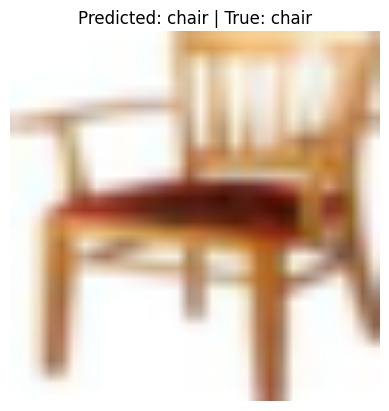

In [189]:
import matplotlib.pyplot as plt

# Get a batch of images from the test_loader
data_iter = iter(test_loader)
images, labels = next(data_iter)

# Select the first image and label from the batch
test_image = images[30].unsqueeze(0).to(device)  # Add batch dimension
true_label = labels[30].item()

# Run inference on the test image
with torch.no_grad():
    outputs, attention_scores = model(test_image)
    _, predicted_class = torch.max(outputs, 1)

# Get the predicted and true labels
cifar100_labels = train_dataset.classes

predicted_label = cifar100_labels[predicted_class.item()]
true_label_name = cifar100_labels[true_label]
print(f"Predicted label: {predicted_label}")
print(f"True label: {true_label_name}")

# Convert the test image tensor to a format suitable for display
test_image_display = (
    test_image.squeeze(0).cpu().permute(1, 2, 0)
)  # Remove batch dimension and rearrange for display
test_image_display = test_image_display * torch.tensor(
    [0.2675, 0.2565, 0.2761]
) + torch.tensor(
    [0.5071, 0.4867, 0.4408]
)  # De-normalize
test_image_display = test_image_display.clip(0, 1)  # Clip values to [0, 1]

# Display the image with the predicted and true labels
plt.imshow(test_image_display)
plt.title(f"Predicted: {predicted_label} | True: {true_label_name}")
plt.axis("off")
plt.show()

### Explore Interpretation Visualization

In [190]:
def split_prediction_and_attention_scores(outputs, attention_scores=None):
    # Standard classification predictions
    predictions = outputs

    # Organize attention scores if provided
    attention_score_dict = {}
    if attention_scores:
        for i, score in enumerate(attention_scores):
            attention_score_dict[f"layer_{i}"] = score.cpu()
    return predictions, attention_score_dict

In [191]:
predictions, attention_score_dict = split_prediction_and_attention_scores(
    outputs, attention_scores
)
len(attention_score_dict)

12

In [192]:
RESOLUTION = 224
PATCH_SIZE = 16

#### Mean Attention Distance

In [193]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def compute_distance_matrix(patch_size, num_patches, length):
    distance_matrix = torch.zeros((num_patches, num_patches))
    for i in range(num_patches):
        for j in range(num_patches):
            if i == j:  # zero distance
                continue
            xi, yi = int(i / length), i % length
            xj, yj = int(j / length), j % length
            distance_matrix[i, j] = patch_size * np.linalg.norm(
                torch.tensor([xi - xj, yi - yj])
            )
    return distance_matrix


def compute_mean_attention_dist(patch_size, attention_weights, model_type):
    num_cls_tokens = 1

    # Remove the CLS token attention (if any)
    attention_weights = attention_weights[..., num_cls_tokens:, num_cls_tokens:]
    num_patches = attention_weights.shape[-1]
    length = int(np.sqrt(num_patches))
    assert length**2 == num_patches, "Num patches is not a perfect square"

    # Compute distance matrix
    distance_matrix = (
        compute_distance_matrix(patch_size, num_patches, length)
        .unsqueeze(0)
        .unsqueeze(0)
    )
    # The attention_weights along the last axis adds to 1
    # this is due to the fact that they are softmax of the raw logits
    # summation of the (attention_weights * distance_matrix)
    # should result in an average distance per token.
    mean_distances = attention_weights * distance_matrix
    mean_distances = torch.sum(
        mean_distances, dim=-1
    )  # Sum along last axis to get average distance per token
    mean_distances = torch.mean(
        mean_distances, dim=-1
    )  # Now average across all the tokens

    return mean_distances

In [194]:
# Build mean distances for each Transformer block
mean_distances = {
    f"{name}_mean_dist": compute_mean_attention_dist(
        patch_size=PATCH_SIZE,
        attention_weights=attention_weight[0],
        model_type="original_vit",
    )
    for name, attention_weight in attention_score_dict.items()
}

# Determine the number of heads from one of the distance outputs
num_heads = mean_distances["layer_0_mean_dist"].shape[-1]
print(f"Num Heads: {num_heads}.")

Num Heads: 12.


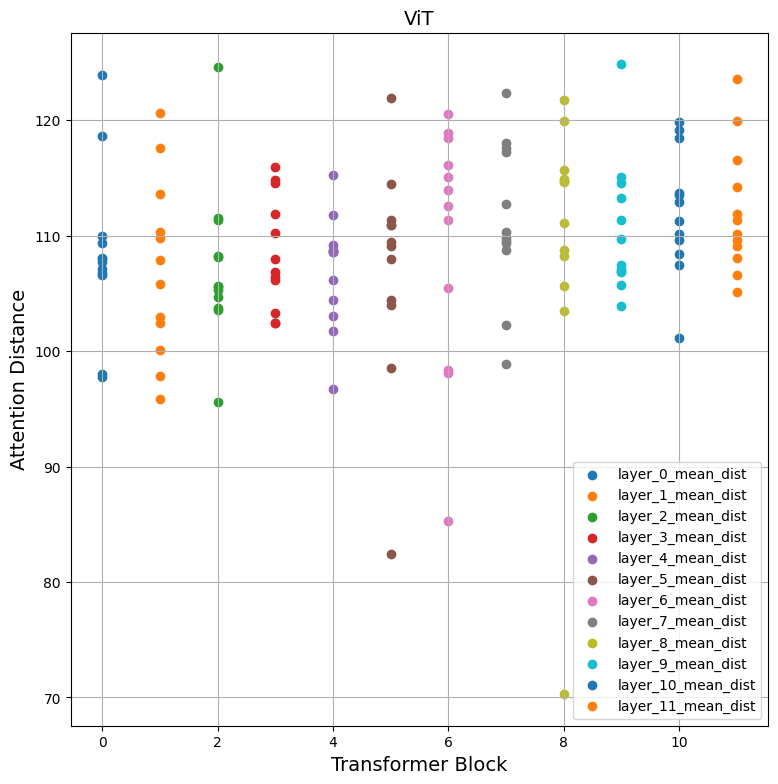

In [195]:
# Plotting mean distances per Transformer block
plt.figure(figsize=(9, 9))
for idx, (name, mean_distance) in enumerate(mean_distances.items()):
    x = [idx] * num_heads
    y = mean_distance[0, :].cpu().numpy()
    plt.scatter(x=x, y=y, label=name)

plt.legend(loc="lower right")
plt.xlabel("Transformer Block", fontsize=14)
plt.ylabel("Attention Distance", fontsize=14)
plt.title("ViT", fontsize=14)
plt.grid()
# plt.show()
plt.savefig("data/" + prefix + "mean_dist")

#### Attention Rollout

In [196]:
import torch
import cv2
import numpy as np


def attention_rollout_map(image, attention_score_dict, model_type):
    num_cls_tokens = 1  # Number of CLS tokens, set based on the model type

    # Stack attention matrices from Transformer blocks
    attn_mat = torch.stack(
        [attention_score_dict[k] for k in attention_score_dict.keys()]
    )  # Shape: [layers, batch, heads, tokens, tokens]
    attn_mat = attn_mat.squeeze(1)  # Remove batch dimension if unnecessary

    # Average the attention weights across all heads
    attn_mat = attn_mat.mean(dim=1)  # Shape: [layers, tokens, tokens]

    # Add identity matrix for residual connections and normalize
    residual_attn = torch.eye(attn_mat.size(-1), device=attn_mat.device)
    aug_attn_mat = attn_mat + residual_attn
    aug_attn_mat = aug_attn_mat / aug_attn_mat.sum(dim=-1, keepdim=True)

    # Convert to numpy for matrix multiplication
    aug_attn_mat = aug_attn_mat.cpu().numpy()

    # Recursive multiplication of attention matrices
    joint_attentions = np.zeros_like(aug_attn_mat)
    joint_attentions[0] = aug_attn_mat[0]
    for n in range(1, aug_attn_mat.shape[0]):
        joint_attentions[n] = np.matmul(aug_attn_mat[n], joint_attentions[n - 1])

    # Extract attention from the final layer (output token to input space)
    v = joint_attentions[-1]
    grid_size = int(np.sqrt(v.shape[-1]))
    mask = v[0, num_cls_tokens:].reshape(grid_size, grid_size)

    # Resize the mask to the original image's dimensions
    height, width = image.shape[:2]  # Get original image dimensions
    mask = cv2.resize(mask / mask.max(), (width, height))[..., np.newaxis]

    return mask

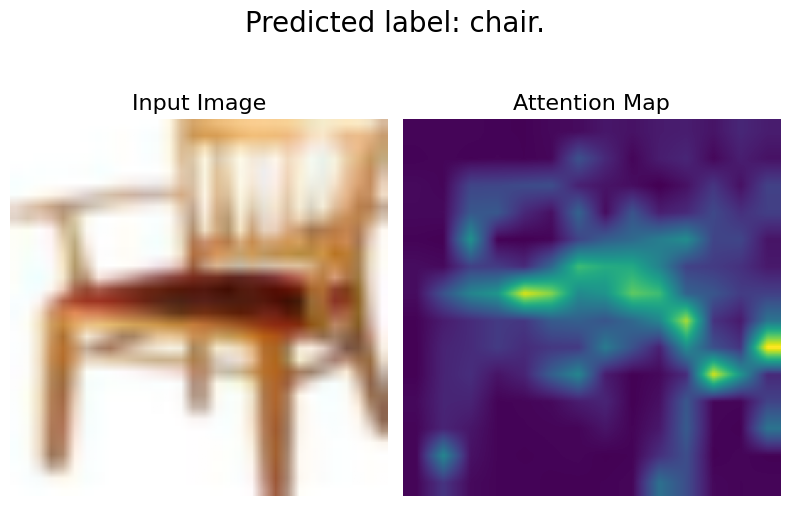

In [197]:
test_image_display = (
    test_image.squeeze(0).cpu().permute(1, 2, 0)
)  # Remove batch dimension and rearrange for display
test_image_display = test_image_display * torch.tensor(
    [0.2675, 0.2565, 0.2761]
) + torch.tensor(
    [0.5071, 0.4867, 0.4408]
)  # De-normalize
test_image_display = test_image_display.clip(0, 1)  # Clip values to [0, 1]

mask = attention_rollout_map(
    test_image_display, attention_score_dict, model_type="original_vit"
)
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 10))
fig.suptitle(f"Predicted label: {predicted_label}.", fontsize=20)


_ = ax1.imshow(test_image_display)
_ = ax2.imshow(mask)
ax1.set_title("Input Image", fontsize=16)
ax2.set_title("Attention Map", fontsize=16)
ax1.axis("off")
ax2.axis("off")

fig.tight_layout()
fig.subplots_adjust(top=1.35)
# fig.show()
plt.savefig("data/" + prefix + "rollout_map")

#### Attention Heatmap

In [198]:
import torch
import torchvision.transforms.functional as TF


def attention_heatmap(attention_score_dict, image, model_type="dino"):
    num_tokens = 1

    # Sort Transformer blocks by their depth
    attention_score_list = list(attention_score_dict.keys())
    attention_score_list.sort(key=lambda x: int(x.split("_")[-1]), reverse=True)

    # Calculate feature map dimensions
    w_featmap = image.shape[1] // PATCH_SIZE
    h_featmap = image.shape[0] // PATCH_SIZE
    attention_scores = attention_score_dict[attention_score_list[0]]
    print(attention_scores.shape)

    # Extract attention from the CLS token
    num_heads = attention_scores.shape[1]
    attentions = attention_scores[0, :, 0, num_tokens:].reshape(num_heads, -1)
    print(attentions.shape)

    # Reshape attention scores into mini patches
    attentions = attentions.reshape(num_heads, w_featmap, h_featmap)
    attentions = attentions.permute(
        1, 2, 0
    )  # Transpose to (w_featmap, h_featmap, num_heads)
    print(attentions.shape)

    # Resize the attention patches to the size of the original image
    attentions_resized = TF.resize(
        attentions, size=(h_featmap * PATCH_SIZE, w_featmap * PATCH_SIZE)
    )
    print(attentions_resized.shape)
    return attentions_resized

torch.Size([1, 12, 197, 197])
torch.Size([12, 196])
torch.Size([14, 14, 12])
torch.Size([14, 224, 224])


/tmp/ipykernel_749312/3598152374.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make room for colorbar


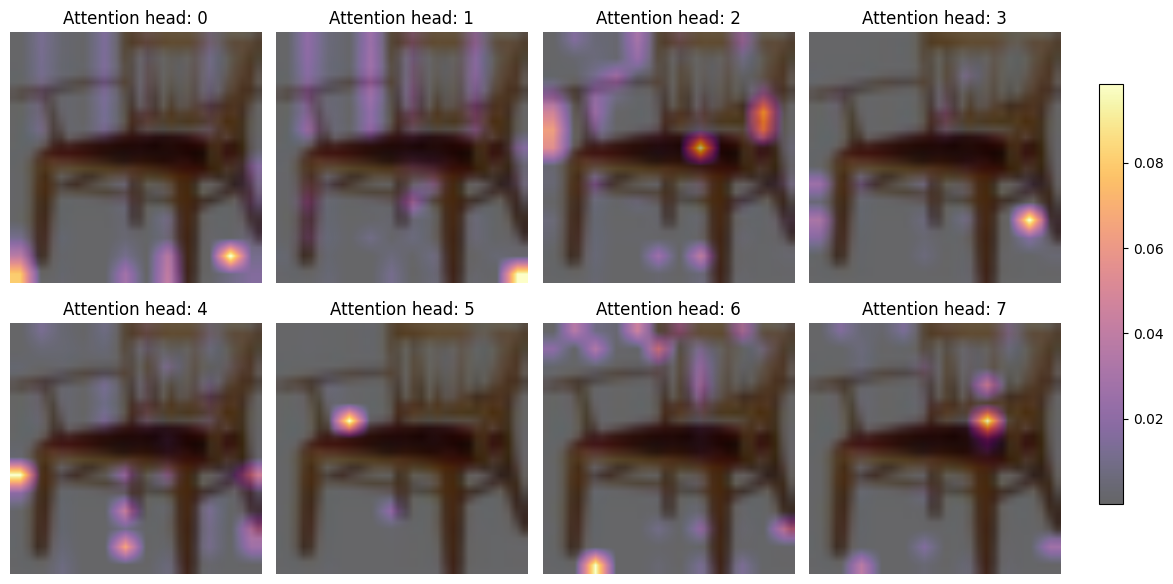

In [199]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Generate the attention heatmaps.
attentions = attention_heatmap(
    attention_score_dict, test_image_display
)  # Assuming `attentions` has shape (num_heads, height, width)

# Plot the maps.
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))
img_count = 0

# Plot each attention head map with a colorbar
for i in range(2):
    for j in range(4):
        if (
            img_count < attentions.shape[-1]
        ):  # Ensure we do not exceed the number of attention heads
            ax = axes[i, j]
            img = ax.imshow(test_image_display)
            heatmap = ax.imshow(
                attentions[img_count].cpu().numpy(), cmap="inferno", alpha=0.6
            )

            ax.title.set_text(f"Attention head: {img_count}")
            ax.axis("off")
            img_count += 1

# Create a single colorbar for all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Position for the colorbar
fig.colorbar(heatmap, cax=cbar_ax, orientation="vertical")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make room for colorbar
# plt.show()
plt.savefig("data/" + prefix + "attention_heatmap")

#### Learned Projections

(768, 3, 16, 16)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


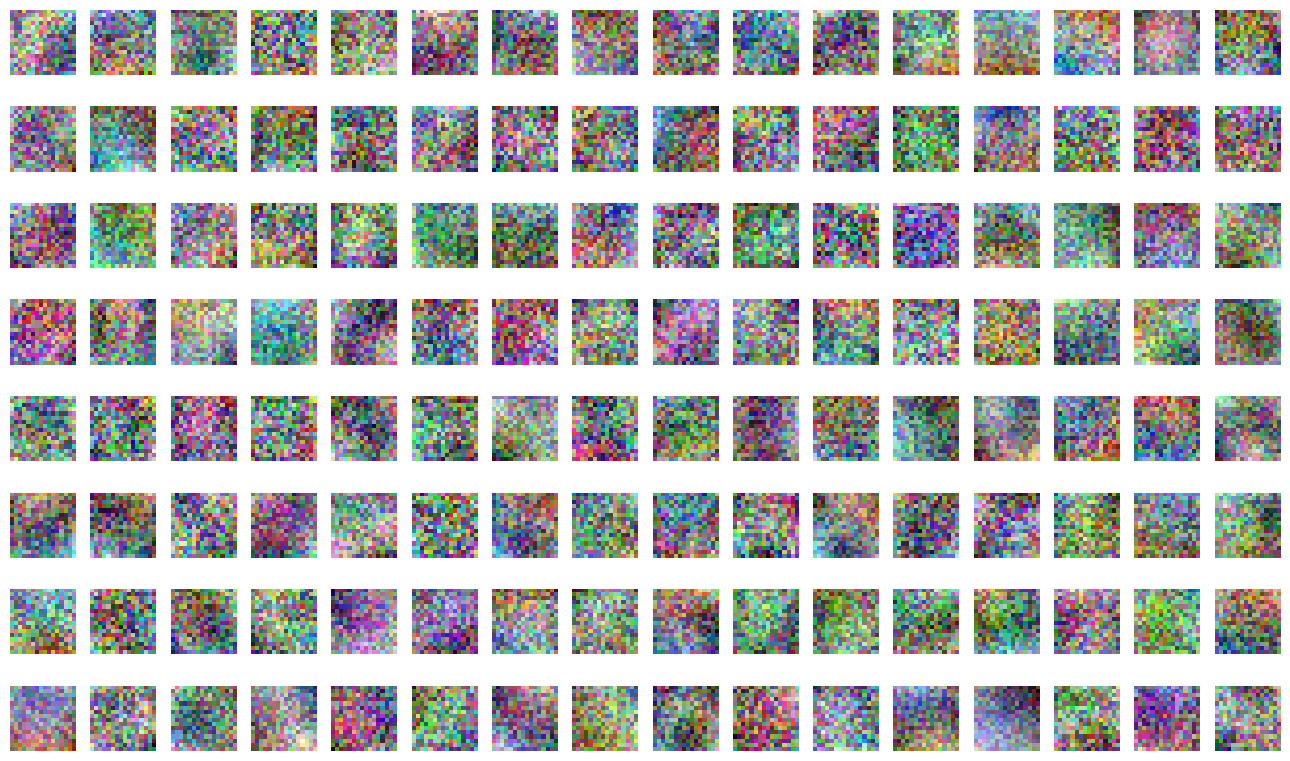

In [122]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler


def extract_weights(model, name):
    # Extract weights for the specified layer
    for param_name, param in model.state_dict().items():
        if param_name.startswith(name):
            return param.cpu().numpy()
    return None


# Assume `vit_base_i21k_patch16_224` is your Vision Transformer model in PyTorch
# Replace `"conv_projection/kernel"` with the specific layer name you want to extract
projections = extract_weights(model, "patch_embed")  # Adjust based on your layer naming
print(projections.shape)

# Check if the projections were successfully extracted
if projections is None:
    print("Layer not found in model.")
else:
    projections = projections.transpose(2, 3, 1, 0)
    projection_dim = projections.shape[
        -1
    ]  # Assuming [out_channels, in_channels, kernel_h, kernel_w]
    patch_h, patch_w, patch_channels = projections.shape[:-1]

    # Scale the projections.
    scaled_projections = MinMaxScaler().fit_transform(
        projections.reshape(-1, projection_dim)
    )

    # Reshape the scaled projections so that the leading
    # Three dimensions resemble an image.
    scaled_projections = scaled_projections.reshape(
        patch_h, patch_w, patch_channels, -1
    )

    # Visualize the first 128 filters of the learned
    # projections.
    fig, axes = plt.subplots(nrows=8, ncols=16, figsize=(13, 8))
    img_count = 0
    limit = 128

    for i in range(8):
        for j in range(16):
            if img_count < limit:
                axes[i, j].imshow(scaled_projections[..., img_count])
                axes[i, j].axis("off")
                img_count += 1

    fig.tight_layout()
    # plt.show()
    plt.savefig("data/" + prefix + "projection_filters")

#### Learned Positional embeddings

(196, 768)


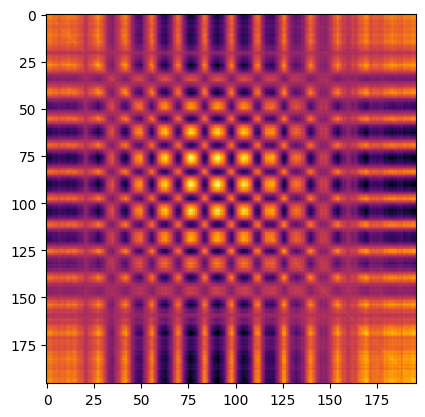

In [123]:
position_embeddings = extract_weights(model, "pos_embedding")

# Discard the batch dimension and the position embeddings of the
# cls token.
position_embeddings = position_embeddings.squeeze()[1:, ...]
print(position_embeddings.shape)

similarity = position_embeddings @ position_embeddings.T
plt.imshow(similarity, cmap="inferno")
# plt.show()
plt.savefig("data/" + prefix + "positional_embeddings")